#### *Project Details*
This project takes a dataset and trains on it using the KNN algorithm to classify correctly then evaluates it.

#### *Importing Libraries*

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pandas is used to load the dataset and explore it.
# Numpy is imported in case of any need to use array and mathematical functionalities.
# Matplot will be used for plotting graphs.

#### *Importing Scikit-Learn Modules*

In [100]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.metrics import ConfusionMatrixDisplay

# StandardScaler is used to scale the features so that they're within similar ranges (where the mean is 0 and the standard deviation is 1).
# KNeighborsClassifier is used for classification.
#train_test_split is used to split the dataset into a training set (80%) and a testing set (20%).
# confusion_matrix and f1_score are used to evaluate the predictions.
# to display the confusion matrix.

#### *Exploring the Dataset*

In [78]:
Zoo = pd.read_csv(r'C:\Users\jojos\OneDrive\Pictures\Desktop\DecodeLabs-AI-Internship\Project 2\Zoo Animals Classification Dataset\zoo.csv')

Zoo.head()

# The dataset was loaded using it's file-path, then it's first 5 instances were displayed.

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


Above, the features of the animals are shown in 0s or 1s, where 0 means that the feature is not present, and 1 means that the feature is present.
This is done to all features but 'legs' as it displays the number of legs present, and 'class_type' as it shows the class number the animal belongs in.

In [79]:
Zoo.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


The above table is a display of more details on each feature. These details include:
- count (the number of rows/instances)
- mean (the average values of that feature)
- std (Standard Deviation)
- min (minimum value, which is 0 for all features but class_type)
- 25% (first quartile)
- 50% (median/second quartile)
- 75% (third quartile)
- max (maximum value, which is 1 for all features but legs and class_type)

In [80]:
Zoo.dtypes

# displays the datatypes of each feature

animal_name      str
hair           int64
feathers       int64
eggs           int64
milk           int64
airborne       int64
aquatic        int64
predator       int64
toothed        int64
backbone       int64
breathes       int64
venomous       int64
fins           int64
legs           int64
tail           int64
domestic       int64
catsize        int64
class_type     int64
dtype: object

In [81]:
Zoo.shape

# displays the shape of the dataset. We have 101 rows/instances and 18 columns/features.

(101, 18)

In [82]:
Zoo.columns

# displays the column names in an array form.

Index(['animal_name', 'hair', 'feathers', 'eggs', 'milk', 'airborne',
       'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous',
       'fins', 'legs', 'tail', 'domestic', 'catsize', 'class_type'],
      dtype='str')

In [83]:
Zoo.info()

# displays more information about the dataset, like whether there are null values or not.

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   animal_name  101 non-null    str  
 1   hair         101 non-null    int64
 2   feathers     101 non-null    int64
 3   eggs         101 non-null    int64
 4   milk         101 non-null    int64
 5   airborne     101 non-null    int64
 6   aquatic      101 non-null    int64
 7   predator     101 non-null    int64
 8   toothed      101 non-null    int64
 9   backbone     101 non-null    int64
 10  breathes     101 non-null    int64
 11  venomous     101 non-null    int64
 12  fins         101 non-null    int64
 13  legs         101 non-null    int64
 14  tail         101 non-null    int64
 15  domestic     101 non-null    int64
 16  catsize      101 non-null    int64
 17  class_type   101 non-null    int64
dtypes: int64(17), str(1)
memory usage: 14.9 KB


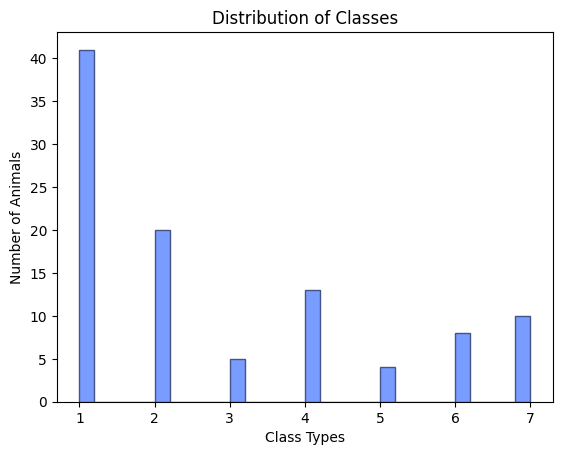

In [84]:
plt.figure()
plt.hist(Zoo['class_type'], bins=30, color="#789cff",edgecolor="#435484")
plt.title("Distribution of Classes")
plt.xlabel("Class Types")
plt.ylabel("Number of Animals")
plt.show()

To display exact values, we will split the dataset into classes. This is shows below:

In [86]:
Mammals = Zoo[Zoo["class_type"] == 1]

Mammals.shape

# displays the shape of a separately created mammal array/dataset with 41 rows/instances/animals and 18 features.

(41, 18)

In [87]:
Birds = Zoo[Zoo["class_type"] == 2]

Birds.shape

# displays the shape of a separately created bird array/dataset with 20 rows/instances/animals and 18 features.

(20, 18)

In [88]:
Reptiles = Zoo[Zoo["class_type"] == 3]

Reptiles.shape

# displays the shape of a separately created reptile array/dataset with 5 rows/instances/animals and 18 features.

(5, 18)

In [89]:
Fish = Zoo[Zoo["class_type"] == 4]

Fish.shape

# displays the shape of a separately created fish array/dataset with 13 rows/instances/animals and 18 features.

(13, 18)

In [90]:
Amphibians = Zoo[Zoo["class_type"] == 5]

Amphibians.shape

# displays the shape of a separately created amphibians array/dataset with 4 rows/instances/animals and 18 features.

(4, 18)

In [91]:
Bugs = Zoo[Zoo["class_type"] == 6]

Bugs.shape

# displays the shape of a separately created bug array/dataset with 8 rows/instances/animals and 18 features.

(8, 18)

In [92]:
Invertebrates = Zoo[Zoo["class_type"] ==7]

Invertebrates.shape

# displays the shape of a separately created invertebrate array/dataset with 10 rows/instances/animals and 18 features.

(10, 18)

#### *Splitting the Dataset*

In [94]:
Zoo1 = Zoo.copy()

x = Zoo1.drop(["animal_name", "class_type"], axis=1)
y = Zoo1["class_type"]

x.shape, y.shape

# Created a copy of the original dataset as to not alter it.
# x was created to be the feature table and y was created to be the target labels.
# x has a size of 101 arows and 16 columns and y has a size of 101 rows and 1 column.

((101, 16), (101,))

In [95]:
xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size=0.2, random_state=42)

xTrain.shape, xTest.shape, yTrain.shape, yTest.shape

# The dataset was split into 80% training, and 20% testing.
# xTrain has a size of 80 rows and 16 features while xTest has a size of 21 rows and 16 features.
# yTrain has a size of 80 rows and 1 feature while yTest has a size of 21 rows and 1 feature.

((80, 16), (21, 16), (80,), (21,))

#### *Scaling the Values/Ranges*

In [96]:
Scaler = StandardScaler()

xTrainScaled = Scaler.fit_transform(xTrain)
xTestScaled = Scaler.transform(xTest)

# A scaler object was created to perform the fitting and transforming.
# Fitting learns the scaling rules from the train set, then transforms (applies) it to the train set and the test set.

#### *Training the KNN*

In [97]:
KNN = KNeighborsClassifier(n_neighbors=5)

KNN.fit(xTrainScaled, yTrain)

# Here, the moddel will look at the 5 nearest examples when predicting a new sample.
# The fitting trains model using the scaled features in the training set and the correct labels for the given rows.

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [98]:
yPredict = KNN.predict(xTestScaled)

# guesses the classes of the testing set by comparing between examples and making a majority vote.

#### *Evaluating the Model*

In [103]:
print("Model Predictions: ", yPredict)

# This prints the predictions the model had made.

Model Predictions:  [1 1 1 1 1 6 1 1 1 1 4 6 6 2 7 1 1 2 4 1 4]


Confusion Matrix:
  [[12  0  0  0  0  0]
 [ 0  2  0  0  0  0]
 [ 0  0  0  1  0  0]
 [ 0  0  0  2  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  1]]


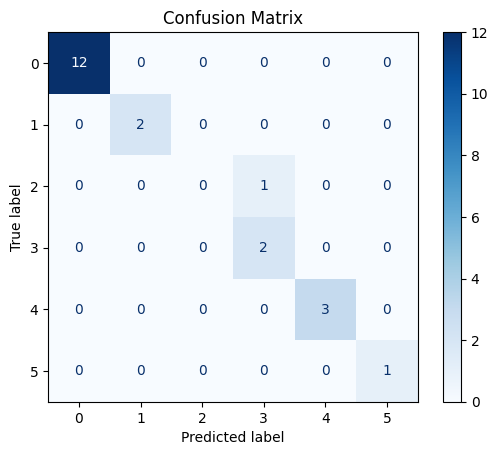

In [104]:
print("Confusion Matrix:\n ", confusion_matrix(yTest, yPredict))

cm = confusion_matrix(yTest, yPredict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# This matrix shows that the values on the diagonal were classified correctly, while the values off the diagonal were misclassified.

In [107]:
print("F1 Score is: ", f1_score(yTest, yPredict, average="weighted"))

F1 Score is:  0.9333333333333333
